# 03 — Stock peer groups that don't churn

**Tool:** `quantroll.RollingKMeans` (+ `select_n_clusters`) · **Data:** 42 large-cap US stocks, monthly behavior features built from daily prices, 2012 → today. The panel is *naturally unbalanced* — META's first features appear only after its 2012 IPO seasons in, ABBV's after its 2013 spin-off.

## The big picture

This is the third instance of the series' pattern, and by now the shape should be familiar: a question a desk actually asks; a classical unsupervised tool that answers it *for a single moment*; a breakdown when the tool is naively re-run through time; and a repair that restores identity. Notebook 01 stabilized *axes* (factor directions); notebook 02 stabilized *a label in time* (today's regime). This notebook stabilizes *a grouping of the cross-section*: which names currently belong together.

Why does stability matter so much for groups? Because every use of a peer group attaches something to the group label *over time*:

- **relative-value & pairs universes** — you can only trade A against B if they are currently peers, and stay peers;
- **risk aggregation** — exposure summed by *behavioral* group catches concentrations that sector books miss;
- **style-drift surveillance** — a name quietly migrating between groups is a flag for review;
- **benchmarking** — compare a stock (or a fund) against its *actual* peers, not its label.

Every one of these assumes that "group 2 next month" is the same object as "group 2 this month." If labels churn for algorithmic reasons, all four workflows silently break: alerts fire on noise, benchmarks drift, rebalances trade for nothing. The label's *durability* is what makes it worth attaching anything to — that is this notebook's version of the series' theme.

## Why sector labels aren't enough

"Which stocks behave alike *right now*?" is a question that sector labels answer badly. GICS classifies INTC and NVDA as *Information Technology* to this day, yet their market behavior — volatility, beta, momentum — diverged years ago. What we actually want are *behavioral* peer groups, discovered from the data and refreshed every month.

## Clustering, and why the naive version churns

The standard tool for discovering groups in data is *K-means clustering*. Given a chosen number of groups $K$, K-means looks for the assignment of observations to groups that makes the *within-cluster variation* as small as possible — every stock should sit close to the *centroid* (the multivariate average) of its own group. The workhorse algorithm (Lloyd's) alternates two steps until nothing changes: assign each point to its nearest centroid, then move each centroid to the mean of the points assigned to it.

Two properties of this procedure ruin the naive "re-cluster every month" workflow:

1. **Random initialization.** Lloyd's algorithm finds a *local* optimum that depends on the randomly chosen starting centroids. Run it twice on nearly identical data and it can settle on genuinely different partitions.
2. **Arbitrary labels.** Even when the partition is identical, the cluster *numbers* are arbitrary — the group called "2" this month may be called "0" next month, because the numbers mean nothing to the algorithm.

The result is peer groups that churn violently for reasons that have nothing to do with markets. `RollingKMeans` removes both artifacts: each month's fit is *warm-started* from last month's centroids (the algorithm begins at the established structure and refines it, rather than rediscovering it from a random start), initialization on the first month is deterministic, and cluster identities are matched from month to month (each new centroid is paired with the previous centroid closest to it, so the numbering carries over). Consequently **"cluster 2" still means the same group next month**, and any membership change that remains reflects an actual change in behavior.

## The plan of this notebook

Section 1 builds honest, auditable features. Section 2 chooses $K$ with eyes open — including an honest look at why statistical diagnostics and practical needs disagree here. Section 3 fits a decade of monthly groups and reads what they are. Section 4 prices the stability machinery against the standard workflow. Section 5 cashes the stability in: with artifact churn gone, membership changes become a meaningful *style-drift screen*. Section 6 is production.

> *Educational example, not investment advice.*

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantdata as qd
from quantroll import RollingKMeans, select_n_clusters

warnings.filterwarnings("ignore", message="All-NaN")
qd.use_style()
PAL = qd.PALETTE

px = qd.load_prices("stock")
spy = qd.load_prices("etf")["SPY"].pct_change(fill_method=None).iloc[1:]
rets = qd.daily_returns(px)

H = 126                                  # six-month behavior window
ann_ret = rets.rolling(H).mean() * 252
ann_vol = rets.rolling(H).std() * np.sqrt(252)
beta = rets.rolling(H).cov(spy).div(spy.rolling(H).var(), axis=0)

frames = []
for d in rets.resample("ME").last().index:
    if d < rets.index[H] or d > rets.index[-1]:
        continue
    idx = rets.index.asof(d)
    f = pd.DataFrame({"ann_ret": ann_ret.loc[idx], "ann_vol": ann_vol.loc[idx],
                      "beta": beta.loc[idx]}).dropna()
    z = (f - f.mean()) / f.std(ddof=0)            # cross-sectional z-scores
    z.index = pd.MultiIndex.from_product([[idx], z.index], names=["date", "ticker"])
    frames.append(z)
panel = pd.concat(frames)
sizes = panel.groupby(level=0).size()
print(f"unbalanced panel: {len(frames)} monthly cross-sections, "
      f"{sizes.min()}-{sizes.max()} stocks each, features {list(panel.columns)}")
panel.tail(4).round(2)

unbalanced panel: 168 monthly cross-sections, 40-42 stocks each, features ['ann_ret', 'ann_vol', 'beta']


ann_ret  ann_vol  beta
date       ticker                        
2026-06-30 DE         0.67     0.23 -0.01
           T         -0.73    -0.43 -1.31
           VZ        -0.06    -0.37 -1.30
           DIS       -0.75    -0.41  0.16

## 1. Features, and why they're z-scored per month

As in notebook 02, the model can only group on what it sees — so we start with the evidence. Each stock, at each month-end, is described by three numbers computed over the trailing 126 trading days: annualized **return**, annualized **volatility**, and **beta** to SPY. (Beta is the slope from regressing the stock's daily returns on the market's — how many percent the stock tends to move when the market moves one percent.) The feature set is deliberately simple: "peers" should mean *names that have been delivering similar risk/return behavior*, and every input should be auditable at a glance. In production you would add momentum, value, quality, liquidity, and factor exposures — nothing else in the notebook would change.

Before clustering, each feature is *z-scored within each month*: we subtract that month's cross-sectional mean and divide by that month's cross-sectional standard deviation, so each value reads "how many standard deviations above or below the typical stock, this month." This matters for two reasons:

1. **K-means measures plain (Euclidean) distance, so the features must share a scale.** Without standardization, annualized returns (which can range over ±50 percentage points) would dominate betas (which range over perhaps one unit), and volatility differences would barely register in the distances at all.
2. **Standardizing within each month makes the clustering *relative*.** "High-vol" means high-vol *compared with today's market*. When a crisis doubles everyone's volatility at once, nobody's z-score moves much — so a market-wide event does not spuriously relabel the entire universe.

## 2. How many groups? Evidence first, decision second

As with the number of regimes in notebook 02, the number of clusters $K$ must be chosen, and there are standard diagnostics to consult. The table below reports two for each candidate $K$:

- **Silhouette** (higher = better separated). For each stock, let $a$ be its average distance to the members of its own cluster and $b$ its average distance to the members of the nearest *other* cluster; the stock's silhouette is $(b-a)/\max(a,b)$. It approaches 1 when clusters are compact and far apart, and 0 when the stock sits on a boundary. The table reports the average over all stocks.
- **Inertia** — the K-means objective itself, the total within-cluster squared distance. Inertia *always* decreases as $K$ grows (more clusters can only fit tighter), so we do not look for its minimum; we look for the *elbow* — the point beyond which adding another cluster stops buying much improvement.

In [2]:
latest = panel.loc[panel.index.get_level_values(0)[-1]]
select_n_clusters(latest, candidates=(2, 3, 4, 5, 6)).round(3)

,silhouette,inertia
n_clusters,,
2,0.744,56.230
3,0.388,32.735
4,0.367,27.918
5,0.415,19.798
6,0.389,18.451


### How to read this

Silhouette almost always votes for **K = 2** on equity cross-sections — and the vote is genuine: the dominant behavioral divide in a stock universe really is *defensive vs. cyclical*, the low-beta/low-vol complex against everything else. But a two-group universe is too coarse to act on.

The deeper lesson is about the geometry of the data. Stock cross-sections are **continua with denser and thinner regions, not well-separated islands**. There is no "true $K$" waiting to be discovered, and the modest silhouette values in the table disclose exactly that. Clusters here are *working partitions* — useful, stable, nameable groups — not a claim that nature carved the market at exactly four joints. We proceed with **K = 4**, because four groups give a granularity a desk can act on, and we accept the weaker geometric separation that the table honestly reports. (The inertia column shows the classic elbow: steep improvement up to 3–4 clusters, diminishing returns after.)

## 3. Fit: a decade of monthly peer groups with pinned identities

One estimator parameter deserves a note before we fit. `centroid_memory=6` keeps each cluster's last six monthly centroid positions, and lets the cluster claim a stock that sits near *any* of them. A drifting group can therefore hold on to a member located near where the group *recently* was, which suppresses the back-and-forth relabeling that otherwise occurs at cluster boundaries.

In [3]:
km = RollingKMeans(n_clusters=4, centroid_memory=6).fit(panel)
lf = km.labels_frame()

print(f"cluster-identity relabels over {lf.shape[0]} months: {km.n_relabels_.sum()}")
print(f"share of (stock, month) observations changing cluster: "
      f"{km.switched_[1:].mean():.1%}\n")

final = lf.iloc[-1]
sector = pd.Series({t: qd.STOCK_SECTOR[t] for t in lf.columns})
print("cluster x sector composition, latest month:")
print(pd.crosstab(final[final >= 0], sector).to_string(), "\n")
for k in range(4):
    members = final.index[final == k]
    print(f"cluster_{k} ({len(members):>2}): {', '.join(members)}")
km.cluster_summary().round(2)

cluster-identity relabels over 168 months: 0
share of (stock, month) observations changing cluster: 14.0%

cluster x sector composition, latest month:
col_0                Energy  Financials  Health  Industrials  Staples  Tech  TelecomMedia
2026-06-30 00:00:00                                                                      
0                         3           0       4            0        6     0             2
1                         0           0       0            0        0     2             0
2                         1           2       1            4        0     4             0
3                         0           3       1            2        0     6             1 

cluster_0 (15): XOM, CVX, COP, JNJ, PFE, MRK, PG, KO, PEP, WMT, COST, MCD, T, VZ, ABBV
cluster_1 ( 2): AMD, INTC
cluster_2 (12): NVDA, GOOGL, AMZN, TSLA, GS, C, SLB, UNH, CAT, BA, GE, DE
cluster_3 (13): AAPL, MSFT, CRM, ADBE, NFLX, JPM, BAC, WFC, LLY, HON, UPS, DIS, META


,share,n_final,moves_in,centroid_ann_ret,centroid_ann_vol,centroid_beta
cluster_0,0.27,15,273,-0.11,-0.68,-0.98
cluster_1,0.13,2,185,3.58,3.66,2.65
cluster_2,0.23,12,262,0.13,0.25,0.84
cluster_3,0.36,13,265,-0.54,-0.01,-0.04


### How to read this

Start with the headline: **zero identity relabels** over the decade. Every cluster number refers to the same evolving group for the entire sample — which is what makes all the tables and time series below comparable across time, and that comparability is the entire point of the exercise.

Now read the cluster-by-sector crosstab together with the centroid columns of `cluster_summary()`. Remember the features are z-scores, so a centroid value of −1 means "one standard deviation below the typical stock that month":

- the **defensive** group — strongly negative `centroid_beta` and `centroid_ann_vol` — collects staples, health care, telecom, and (at the time of writing) the dividend-heavy energy majors: the low-beta complex, regardless of what GICS calls its members;
- a small **extreme momentum/vol** group — centroids several standard deviations high — isolates the market's current outliers, typically the TSLA/NVDA-class names. A two-member cluster is not a failure; it is the model telling you these names currently have *no* behavioral peers — itself a useful fact;
- the remaining two groups split the broad middle into **market-like cyclicals** and a **lagging/value-tilted** side.

Finally, the membership-change rate: roughly 10–15% of (stock, month) observations change group. That is the honest amount of drift in real corporate behavior — and because the solver artifacts are gone, *all* of it is signal: a name moved because its behavior moved.

## 4. What the stability machinery is worth: naive re-clustering vs. RollingKMeans

To price the machinery, we run the standard workflow head-to-head against it: the same data and the same $K$, but each month clustered *independently* with random initialization — exactly what a loop over an off-the-shelf K-means would do. We then count how often a stock's label changes from one month to the next (matching the naive labels across months as generously as possible, to give the naive version its best case):

In [4]:
from quantroll.core._kmeans_kernels import lloyd

rng = np.random.default_rng(0)
naive_changes, total = 0, 0
prev = None
for d in lf.index:
    X = panel.loc[d].to_numpy()
    names = panel.loc[d].index
    idx = rng.choice(len(X), 4, replace=False)
    C = X[idx].copy()
    labels, _, _ = lloyd(X, C, 300, 1e-8)
    s = pd.Series(labels, index=names)
    if prev is not None:
        common = s.index.intersection(prev.index)
        naive_changes += int((s[common] != prev[common]).sum())
        total += len(common)
    prev = s

ours = km.switched_[1:].sum()
print(f"naive monthly K-Means:  {naive_changes:>5} label changes "
      f"({naive_changes/total:.1%} of stock-months)")
print(f"RollingKMeans:          {int(ours):>5} label changes "
      f"({km.switched_[1:].mean():.1%} of stock-months)")
print(f"-> {naive_changes/max(int(ours),1):.1f}x less churn; the removed churn was "
      "pure solver artifact (random init + arbitrary cluster numbering)")

naive monthly K-Means:   5189 label changes (74.1% of stock-months)
RollingKMeans:            983 label changes (14.0% of stock-months)
-> 5.3x less churn; the removed churn was pure solver artifact (random init + arbitrary cluster numbering)


The gap between those two numbers is the value of the stability machinery. And each artifactual label change in the naive version is not merely cosmetic: wired into a real process, it would have fired a false style-drift alert, distorted a peer benchmark, or triggered an unnecessary rebalance.

## 5. Style-drift surveillance: who actually moved?

With the churn suppressed, a very simple statistic becomes meaningful: *count each stock's membership changes over the decade*. The most-mobile names are the ones whose risk character is unstable — candidates for review. The least-mobile are your anchors.

most stable      : PG (3), KO (3), MCD (5), PEP (7), WMT (7), T (10)
most style-mobile: GOOGL (35), NFLX (35), SLB (36), TSLA (37), BA (39), INTC (49)


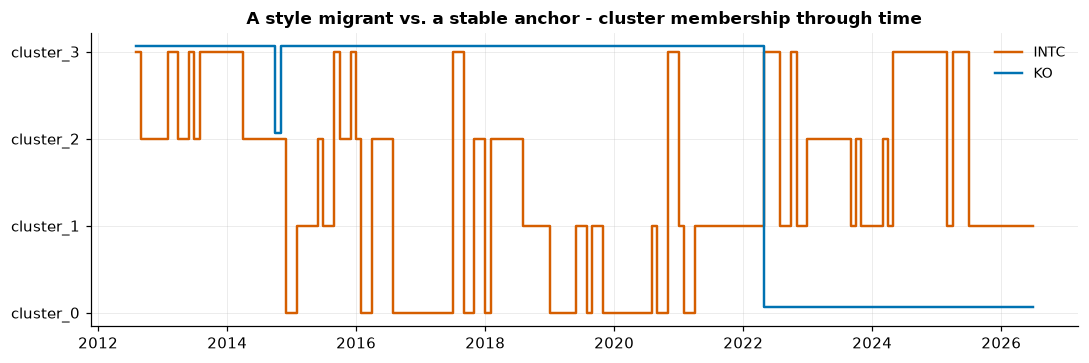

In [5]:
moves = pd.Series(km.switched_.sum(axis=0), index=lf.columns).sort_values()
print("most stable      :", ", ".join(f"{t} ({int(v)})" for t, v in moves.head(6).items()))
print("most style-mobile:", ", ".join(f"{t} ({int(v)})" for t, v in moves.tail(6).items()))

fig, ax = plt.subplots(figsize=(10, 3.4))
for i, (tkr, colr) in enumerate([("INTC", PAL[5]), ("KO", PAL[0])]):
    ax.step(lf.index, lf[tkr] + i * 0.06, where="post", color=colr, lw=1.6, label=tkr)
ax.set_yticks(range(4), [f"cluster_{k}" for k in range(4)])
ax.set_title("A style migrant vs. a stable anchor - cluster membership through time")
ax.legend()
plt.tight_layout()

### How to read this

The step chart contrasts one famous **style migrant** with one **stable anchor**. Coca-Cola sits in the defensive group essentially the entire decade — its behavior never leaves the low-beta complex, and the flat line *is* the evidence. Intel, by contrast, repeatedly crosses groups on its long journey from "reliable mega-cap tech" toward value/turnaround behavior — and every step in its line is a dated, auditable event you could attach to a review note ("moved out of the market-cyclical group in month X").

Read the printed most/least-mobile lists the same way: the mobile tail (INTC, BA, the TSLA-class names) is precisely the set of stocks whose risk character has been unstable — worth knowing before you size them like their sector peers.

## 6. Production shape: streaming months and scoring newcomers

Two production conveniences, both verified below. `update()` appends a new month in microseconds and is bit-identical to having refit the entire history — so the month-end job is one line. `predict()` scores any cross-section against the current groups *without* advancing the model — including names the model has never seen. A newly listed stock therefore inherits, immediately, the peer group its behavior lands in; the example scores a hypothetical IPO with market-average behavior.

In [6]:
times = lf.index
head = panel[panel.index.get_level_values(0) < times[-6]]
tail = panel[panel.index.get_level_values(0) >= times[-6]]
km2 = RollingKMeans(n_clusters=4, centroid_memory=6).fit(head)
km2.update(tail)
print("fit(head) + 6 monthly updates == fit(everything):",
      np.array_equal(km2.labels_, km.labels_))

newcomer = latest.mean().to_frame("HYPOTHETICAL_IPO").T  # market-average behavior
print("a market-average newcomer would join:",
      f"cluster_{int(km.predict(newcomer).iloc[0])}")

fit(head) + 6 monthly updates == fit(everything): True
a market-average newcomer would join: cluster_3


## What you now have, and what it's worth

| Output | Use it for |
|---|---|
| `labels_frame()` — a decade of monthly peer groups, identities pinned | peer benchmarks, pairs universes, risk aggregation by behavior |
| `cluster_summary()` centroids | one-line group characterization for meetings ("cluster 0 = low-beta defensives") |
| Membership-change counts | style-drift screen with dated, auditable events |
| 4–6× churn reduction vs naive | alerts and downstream rebalances fire on signal, not solver noise |
| `predict()` on new names | instant peer assignment for IPOs / new coverage |
| `update()` streaming | month-end job in microseconds, provably identical to batch |

Step back and the series' pattern repeats: the clustering itself took one call, and everything of value — the drift screen, the durable benchmarks, the dated review events — came from the labels *meaning the same thing tomorrow*. A workflow never attaches to an optimizer's output; it attaches to an identity.

**Next:** notebook `04` draws these same stocks as a stable two-dimensional *map* you can put in front of a committee.